## Q1

# TODO:
- Thinning? General best practises for MCMC and summary stats

In [1]:
from coalmine.constants import N, L
from coalmine.data import load_intervals, accident_dates, mean_rate
from coalmine.plotting import plot_cumulative_accidents

In [2]:
intervals = load_intervals()
print(intervals[:10])
print(intervals.shape)

[157. 123.   2. 124.  12.   4.  10. 216.  80.  12.]
(190,)


<Axes: title={'center': 'Cumulative Coal Mining Accidents (1851–1962)'}, xlabel='Date', ylabel='Cumulative number of accidents'>

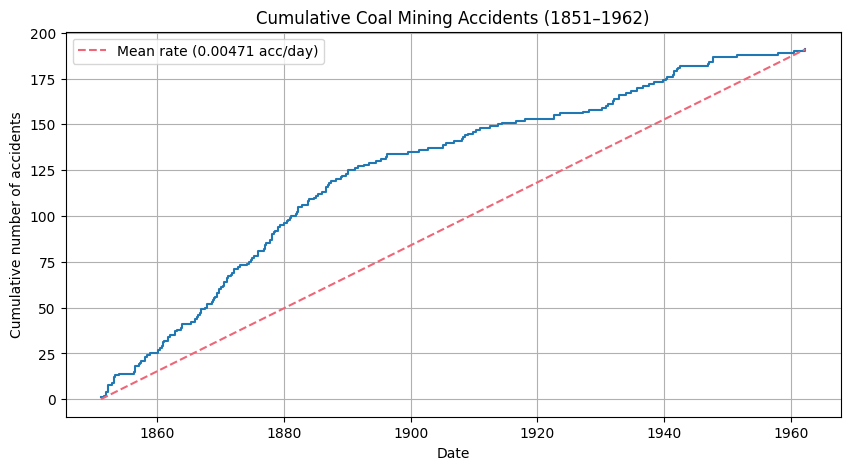

In [3]:
dates = accident_dates(intervals)
plot_cumulative_accidents(dates, mean_rate=mean_rate(), save_as="q1_cumulative_accidents")

#### Mean Rate

Simply the total number of accidents (191) over the entire time period (40550)

In [4]:
print(f"Mean rate: {mean_rate():.17f} accidents per day")

Mean rate: 0.00471023427866831 accidents per day


## Q2 - Priors

### Q2a — Comparing change-point priors

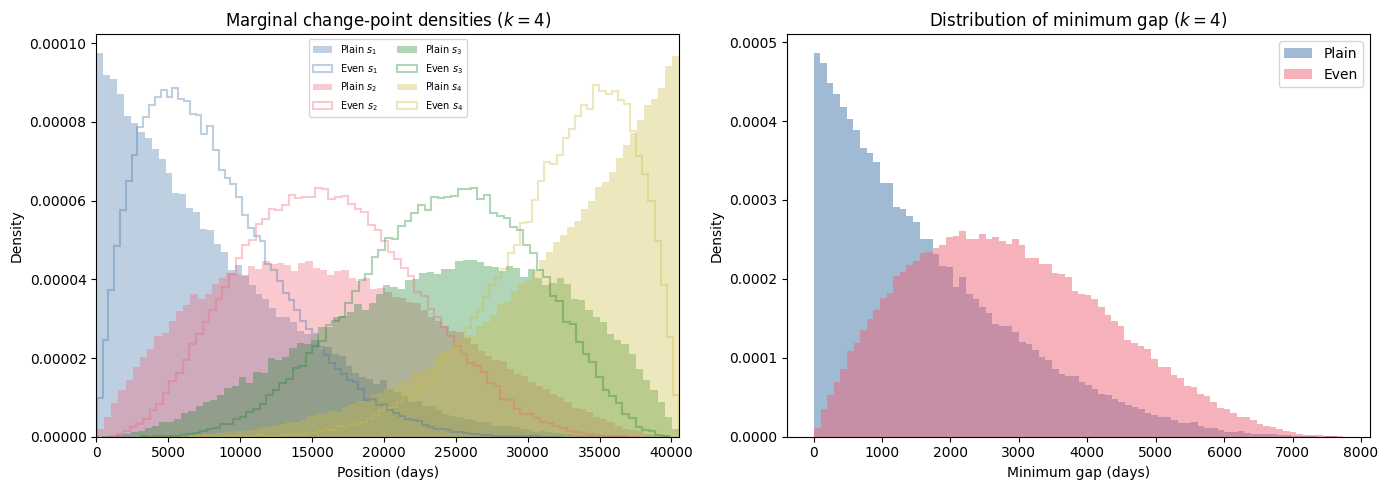

In [5]:
import numpy as np
from coalmine.constants import L
from coalmine.analysis import sample_order_stats
from coalmine.plotting import plot_changepoint_prior_comparison

k = 4
n_samples = 100_000
rng = np.random.default_rng(42)

plain = sample_order_stats(k, n_samples, L, even=False, rng=rng)
even = sample_order_stats(k, n_samples, L, even=True, rng=rng)

# This plot shows the probability distribution of individual change points,
# for s_i, i={1,2,3,4}. You can see how even ordered change points more
# closely align with the midpoint of their position in the range.
fig = plot_changepoint_prior_comparison(plain, even, k, L, save_as="q2a_changepoint_priors")

### TODO: add observations about the even and plain order change points, using information from both graphs

### Q2b

PDF of the plain order statistics is a constant:  
$$
P(u_{(1)}, u_{(2)}, \ldots, u_{(2k+1)}) = (2k + 1)!
$$

To begin, I will consider the points $\hat{s}_j$ on the unit interval, with $\hat{s}_j = u_{(2j)}$.

To get $k$ even ordered change points, we need $2k+1$ plain ordered change points. However, we only care about the probability over the points $\hat{s}_j = u_{(2j)}$, so we have to marginalise out all of the odd points. Consider the point $u_{(2j-1)}$, this is an odd point so I want to marginalise it out. Because the points are ordered, its region of support is bounded by $[\hat{s}_{j-1}, \hat{s}_j]$. Because $u_{(2j-1)}$ is uniformly distributed, the integral is simple:
$$
\int_{\hat{s}_{j-1}}^{\hat{s}_j}1\cdot du_{(2j-1)} = \hat{s}_{j}-\hat{s}_{j-1}
$$

As defined in the question, $s_{j}-s_{j-1} = g_j$.

Marginalising over successive terms in $P(u_{(1)}, u_{(2)}, \ldots, u_{(2k+1)})$, starting with $u_{(1)}$,
$$
\int_{0}^{\hat{s}_1} (2k+1)! \cdot du_{(1)} = \hat{s}_1(2k+1)!
$$

Second term:
$$
\int_{\hat{s}_1}^{\hat{s}_2} \hat{s}_1(2k+1)! \cdot du_{(3)} = \hat{s}_1(\hat{s}_2-\hat{s}_1)(2k+1)!
$$

Continuing this pattern, each successive odd point $u_{(2j-1)}$ contributes a factor of $(\hat{s}_j - \hat{s}_{j-1})$, i.e. the gap $\hat{g}_j$ (using the convention $\hat{s}_0 = 0$, $\hat{s}_{k+1} = 1$). The final odd point $u_{(2k+1)}$ has support $[\hat{s}_k, 1]$ and contributes a factor $(1 - \hat{s}_k) = \hat{g}_{k+1}$. In total there are $k+1$ such integrals, giving:

$$
P(\hat{s}_1, \hat{s}_2, \ldots, \hat{s}_k) = (2k+1)! \prod_{j=1}^{k+1} \hat{g}_j \propto \prod_{j=1}^{k+1} \hat{g}_j
$$

Since scaling to $[0, L]$ via $s_j = L\hat{s}_j$ merely rescales each gap as $g_j = L\hat{g}_j$, the proportionality carries over directly:

$$
\pi(s_1, s_2, \ldots, s_k \mid M_k) \propto \prod_{j=1}^{k+1} g_j
$$

## Q3 - The constant rate model

### a)

**Prior on $h_0$:**
$$
\pi(h_0) = \beta^\alpha\exp(-\beta h_0)/\Gamma(\alpha); \alpha=1,\beta=200\\
\pi(h_0) = 200\exp(-200 h_0)
$$

**Likelihood where $x(t)=h_0$:**
$$
L(\{I_i\} | h_0, M_0) = \frac{h_0^N}{e^{h_0L}}
$$

So un-normalised posterior is
$$
\frac{200h_0^N}{e^{h_0(L+200)}}
$$

To plot the posterior sensibly against the prior, the posterior needs to be normalised. The evidence integral is
$$
Z_0 = \int_0^{\infty} \frac{200h_0^N}{e^{h_0(L+200)}} dh_0
$$

which we use to normalise the posterior

$$Z_0 = 200 \int_0^{\infty} h_0^{N} e^{-h_0(L+200)} dh_0 = 200 \cdot \frac{\Gamma(N+1)}{(L+200)^{N+1}} = \frac{\beta^\alpha \Gamma(\alpha + N)}{(\beta + L)^{\alpha+N}}$$

Analytic log-evidence:  log(Z_0) = -1217.0925
Numerical log-evidence: log(Z_0) = -1217.0925


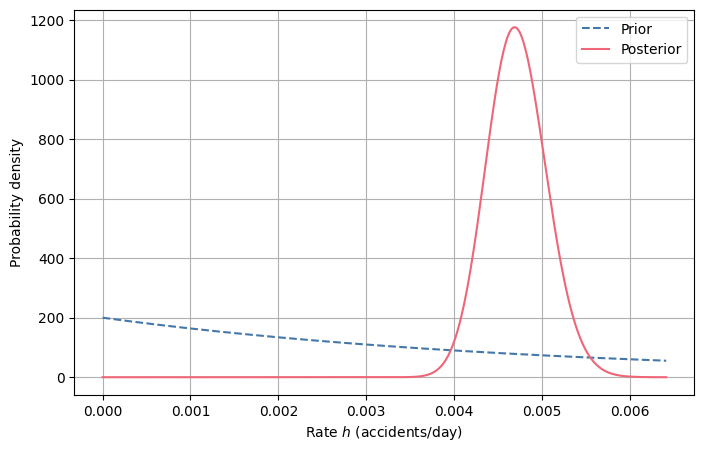

In [6]:
from coalmine.analysis import m0_log_evidence, m0_log_evidence_numerical
from coalmine.plotting import plot_m0_prior_posterior

plot_m0_prior_posterior(save_as="q3a_m0_prior_posterior")

log_Z0_analytic = m0_log_evidence() #? These seem fine, cross checked
log_Z0_numerical = m0_log_evidence_numerical()
print(f"Analytic log-evidence:  log(Z_0) = {log_Z0_analytic:.4f}") #
print(f"Numerical log-evidence: log(Z_0) = {log_Z0_numerical:.4f}")

TODO: ADD OBSERVARTIONS ABOUT THE ABOVE PLOT
- Had to take the log evidence because the values are so so small.

## Q4 — The 1 change-point model, $M_1$

### a) MCMC posterior sampling

We sample the $M_1$ posterior using `emcee`, an affine-invariant ensemble sampler (Foreman-Mackey et al., 2013). Unlike gradient-based samplers (e.g. NUTS), emcee only requires pointwise evaluation of the log-posterior, so we can use the **exact** piecewise-constant likelihood with no sigmoid smoothing.

In [7]:
import emcee
import corner
import numpy as np
from scipy.stats import gamma as gamma_dist, beta as beta_dist
from coalmine.constants import ALPHA, BETA, N, L, SEED
from coalmine.data import load_intervals
from coalmine.plotting import CB_COLOURS

intervals = load_intervals()
times = np.insert(np.cumsum(intervals), 0, 0)  # accident times from t=0


def log_prior_m1(theta):
    """Log-prior for M1: Gamma(1,200) on h0,h1; Beta(2,2)*L on s1."""
    h0, h1, s1 = theta
    if h0 <= 0 or h1 <= 0 or s1 <= 0 or s1 >= L:
        return -np.inf
    lp = gamma_dist.logpdf(h0, a=ALPHA, scale=1 / BETA)
    lp += gamma_dist.logpdf(h1, a=ALPHA, scale=1 / BETA)
    lp += beta_dist.logpdf(s1 / L, a=2, b=2) - np.log(L)  # Jacobian for s1 = L*u
    return lp


def log_likelihood_m1(theta):
    """Exact M1 log-likelihood (piecewise-constant Poisson process)."""
    h0, h1, s1 = theta
    n0 = np.sum(times < s1)
    n1 = N - n0
    return n0 * np.log(h0) + n1 * np.log(h1) - h0 * s1 - h1 * (L - s1)


def log_prob_m1(theta):
    lp = log_prior_m1(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_m1(theta)


# Initialise walkers in a tight ball around a sensible starting point
ndim, nwalkers = 3, 32
rng = np.random.default_rng(SEED)
p0 = rng.normal(
    loc=[0.009, 0.003, 14_000],
    scale=[0.001, 0.0005, 500],
    size=(nwalkers, ndim),
)

# Run emcee
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob_m1)
# Burn-in
state = sampler.run_mcmc(p0, 2000, progress=True)
sampler.reset()
# Production
state = sampler.run_mcmc(state, 10000, progress=True)

print(f"Acceptance fraction: {sampler.acceptance_fraction.mean():.3f}")
print(f"Shape of chain: {sampler.get_chain().shape}  (steps, walkers, params)")

/Users/rowandauria/Documents/MPhil/S2/s2-coursework/venv/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
100%|██████████| 10000/10000 [00:23<00:00, 419.41it/s]

Acceptance fraction: 0.524
Shape of chain: (10000, 32, 3)  (steps, walkers, params)


Autocorrelation times: h0=49.1, h1=48.9, s1=48.2
Effective samples: 6522
h0: 0.008557  (+0.000827 / -0.000774)
h1: 0.002544  (+0.000330 / -0.000303)
s1: 14361.538317  (+738.154923 / -794.052645)


PosixPath('/Users/rowandauria/Documents/MPhil/S2/s2-coursework/figs/q4a_m1_trace_plots')

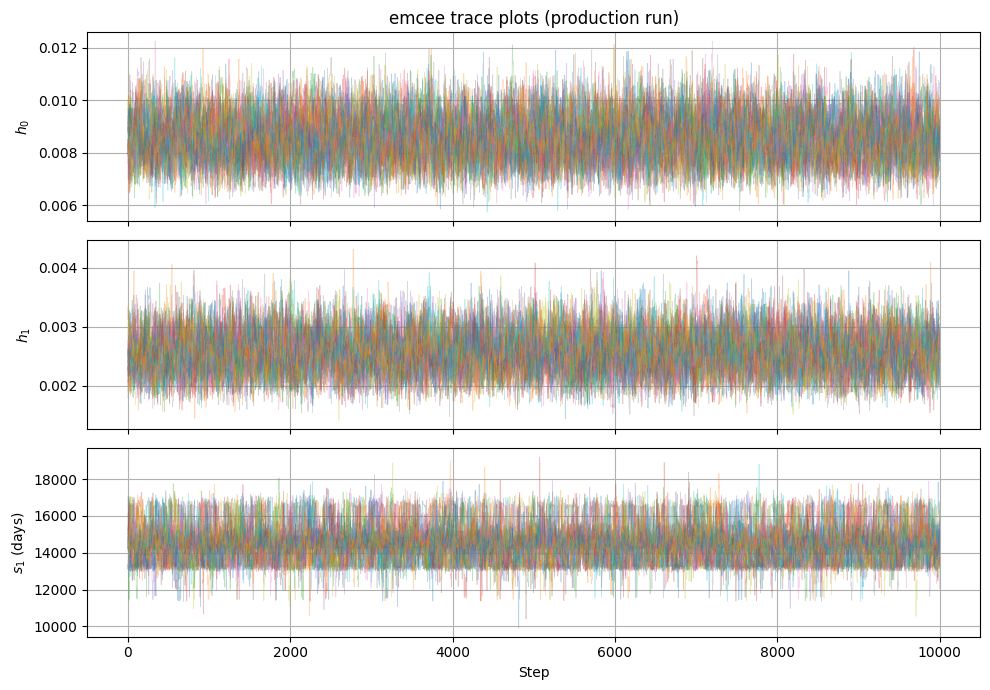

In [8]:
# Diagnostics: autocorrelation time and trace plots
import matplotlib.pyplot as plt

try:
    tau = sampler.get_autocorr_time()
    print(f"Autocorrelation times: h0={tau[0]:.1f}, h1={tau[1]:.1f}, s1={tau[2]:.1f}")
    print(f"Effective samples: {sampler.get_chain().shape[0] * nwalkers / tau.max():.0f}")
except emcee.autocorr.AutocorrError as e:
    print(f"Autocorrelation warning: {e}")

# Trace plots
chain = sampler.get_chain()  # (steps, walkers, ndim)
labels = [r"$h_0$", r"$h_1$", r"$s_1$ (days)"]
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.plot(chain[:, :, i], alpha=0.3, linewidth=0.5)
    ax.set_ylabel(label)
    ax.grid(True)
axes[-1].set_xlabel("Step")
axes[0].set_title("emcee trace plots (production run)")
fig.tight_layout()

# Summary statistics
flat_samples = sampler.get_chain(flat=True)
for i, label in enumerate(["h0", "h1", "s1"]):
    q = np.percentile(flat_samples[:, i], [16, 50, 84])
    print(f"{label}: {q[1]:.6f}  (+{q[2]-q[1]:.6f} / -{q[1]-q[0]:.6f})")

from coalmine.plotting import savefig
savefig(fig, "q4a_m1_trace_plots")


PosixPath('/Users/rowandauria/Documents/MPhil/S2/s2-coursework/figs/q4a_m1_corner')

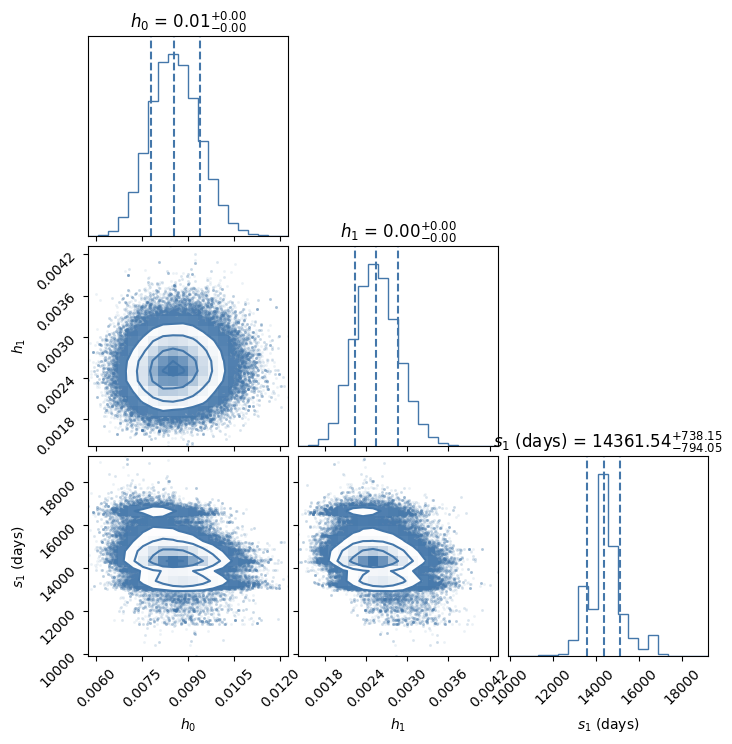

In [9]:
# Corner plot
flat_samples = sampler.get_chain(flat=True)

fig = corner.corner(
    flat_samples,
    labels=[r"$h_0$", r"$h_1$", r"$s_1$ (days)"],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    color=CB_COLOURS[0],
)

from coalmine.plotting import savefig
savefig(fig, "q4a_m1_corner")


# KEY POINTS:
* degeneracy
* deep in the tail of the posterior so will be dividing by zero - can't compute
* Symmetrical prior means the values spread out

### b) Savage-Dickey density ratio

The Savage-Dickey density ratio computes the Bayes factor between nested models without evaluating evidences directly. If $M_0$ is recovered from $M_1$ by fixing a parameter $\psi = \psi_0$, then:

$$B_{01} = \frac{Z_0}{Z_1} = \frac{p(\psi_0 \mid \{I_i\}, M_1)}{\pi(\psi_0 \mid M_1)}$$

Here, $M_0$ is nested in $M_1$ at $h_0 = h_1$ (equivalently $\delta = h_0 - h_1 = 0$), so in principle we need the ratio of posterior to prior density at $\delta = 0$.

**The difficulty** is twofold. First, the unconstrained $M_1$ posterior (Q4a) concentrates around $\delta \approx 0.006$, far from zero — the data strongly favour distinct rates. No MCMC samples visit $\delta \approx 0$, so any density estimate there is unreliable. Second, as shown below, when we enforce $h_0 = h_1$ the change point $s_1$ becomes **completely unidentifiable**: with equal rates on both sides, $s_1$ has no effect on the likelihood and simply follows its prior. This degeneracy at the nested point means the $M_1$ posterior surface has a flat, uninformative ridge precisely where Savage-Dickey needs a well-defined density value.

When h0 = h1, the change point s1 has no effect on the likelihood.
The posterior on s1 is identical to the prior — the data tell us nothing about s1.
This degeneracy makes the Savage-Dickey density ratio impractical to evaluate.


PosixPath('/Users/rowandauria/Documents/MPhil/S2/s2-coursework/figs/q4b_savage_dickey')

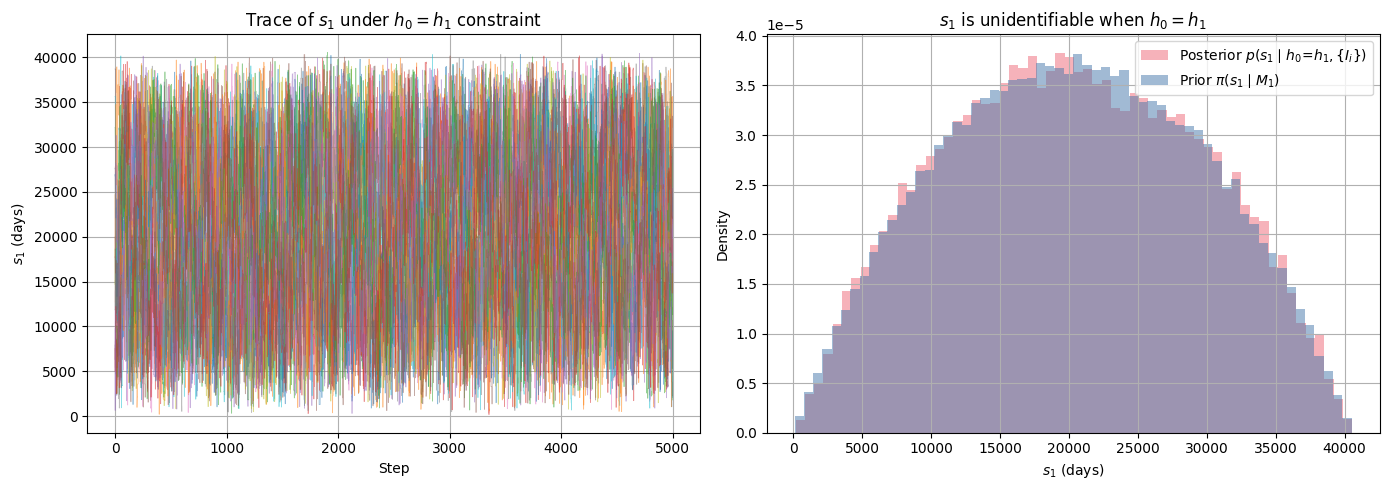

In [10]:
# Run M1 with the constraint h0 = h1 (i.e. δ = 0) to illustrate the difficulty.
# If Savage-Dickey were practical, we'd need the posterior density at this
# nested point. Instead, we show what the posterior looks like *at* the
# nested point: s1 becomes completely unidentifiable.

import emcee
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gamma as gamma_dist, beta as beta_dist
from coalmine.constants import ALPHA, BETA, N, L, SEED
from coalmine.plotting import CB_COLOURS


def log_prob_m1_constrained(theta):
    """Log-posterior for M1 with h0 = h1 = h. Parameters: (h, s1)."""
    h, s1 = theta
    if h <= 0 or s1 <= 0 or s1 >= L:
        return -np.inf
    lp = gamma_dist.logpdf(h, a=ALPHA, scale=1 / BETA)
    lp += beta_dist.logpdf(s1 / L, a=2, b=2) - np.log(L)
    # With h0 = h1 = h, log-likelihood is just M0: N*log(h) - h*L
    lp += N * np.log(h) - h * L
    return lp


ndim_c, nwalkers_c = 2, 16
rng = np.random.default_rng(SEED)
p0_c = rng.normal(
    loc=[0.005, L / 2],
    scale=[0.001, 3000],
    size=(nwalkers_c, ndim_c),
)

sampler_c = emcee.EnsembleSampler(nwalkers_c, ndim_c, log_prob_m1_constrained)
state_c = sampler_c.run_mcmc(p0_c, 1000, progress=False)  # burn-in
sampler_c.reset()
sampler_c.run_mcmc(state_c, 5000, progress=False)  # production

# Compare s1 posterior (constrained) vs the Beta(2,2) prior
s1_samples = sampler_c.get_chain(flat=True)[:, 1]
s1_prior = np.random.default_rng(42).beta(2, 2, size=100_000) * L

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: s1 trace plot — no structure, just noise
ax = axes[0]
chain_c = sampler_c.get_chain()  # (steps, walkers, 2)
ax.plot(chain_c[:, :, 1], alpha=0.5, linewidth=0.5)
ax.set_xlabel("Step")
ax.set_ylabel("$s_1$ (days)")
ax.set_title("Trace of $s_1$ under $h_0 = h_1$ constraint")
ax.grid(True)

# Right panel: s1 histogram vs prior — they are identical
ax = axes[1]
ax.hist(s1_samples, bins=60, density=True, alpha=0.5,
        color=CB_COLOURS[1], label=r"Posterior $p(s_1 \mid h_0\!=\!h_1, \{I_i\})$")
ax.hist(s1_prior, bins=60, density=True, alpha=0.5,
        color=CB_COLOURS[0], label=r"Prior $\pi(s_1 \mid M_1)$")
ax.set_xlabel("$s_1$ (days)")
ax.set_ylabel("Density")
ax.set_title("$s_1$ is unidentifiable when $h_0 = h_1$")
ax.legend()
ax.grid(True)

fig.tight_layout()
print("When h0 = h1, the change point s1 has no effect on the likelihood.")
print("The posterior on s1 is identical to the prior — the data tell us nothing about s1.")
print("This degeneracy makes the Savage-Dickey density ratio impractical to evaluate.")

from coalmine.plotting import savefig
savefig(fig, "q4b_savage_dickey")


### c) Laplace approximation

The Laplace approximation estimates the evidence by approximating the un-normalised posterior as a multivariate Gaussian centred on its mode (the MAP estimate):

$$Z_1 \approx (2\pi)^{d/2} |\hat{\Sigma}|^{1/2} \, \mathcal{L}(\hat{\theta}) \, \pi(\hat{\theta}),$$

where $d = 3$ is the number of parameters, $\hat{\theta}$ is the MAP, and $\hat{\Sigma}$ is the inverse of the negative Hessian of the log-posterior at the MAP.

**The difficulty:** the $M_1$ log-likelihood contains a hard step function — the rate switches discontinuously at $s_1$. An event at time $y_i$ contributes $\log h_0$ if $y_i < s_1$ and $\log h_1$ otherwise. At values of $s_1$ where an event time $y_i$ crosses the change point, the log-likelihood has a **discontinuous jump** (not merely a kink). This means the Hessian $\partial^2 \log P / \partial s_1^2$ is not well defined — it is zero almost everywhere (the log-likelihood is piecewise linear in $s_1$ between adjacent events) with delta-function singularities at each event time. The Gaussian approximation is therefore invalid: the posterior is not smooth in $s_1$, and the Laplace approximation breaks down.

### d) Nested sampling for $M_1$ evidence

We use `dynesty` to compute $Z_1$ via nested sampling. The log-likelihood and prior transform are defined directly from the $M_1$ model:

- **Parameters** (in unit hypercube): $(u_0, u_1, u_2)$ mapped to $(h_0, h_1, s_1)$.
- **Prior transform**: $h_0, h_1$ via inverse Gamma CDF; $s_1$ via inverse Beta(2,2) CDF scaled to $[0, L]$.
- **Log-likelihood**: the exact piecewise-constant Poisson process likelihood (no sigmoid approximation needed — dynesty does not require gradients).

In [11]:
import numpy as np
from scipy.stats import gamma as gamma_dist, beta as beta_dist
from dynesty import NestedSampler
from coalmine.constants import ALPHA, BETA, N, L, SEED
from coalmine.data import load_intervals
from coalmine.analysis import m0_log_evidence

intervals = load_intervals()
times = np.insert(np.cumsum(intervals), 0, 0)  # shape (N,), accident times


def prior_transform(u):
    """Map unit cube [0,1]^3 -> (h0, h1, s1) under M1 priors."""
    h0 = gamma_dist.ppf(u[0], a=ALPHA, scale=1 / BETA)
    h1 = gamma_dist.ppf(u[1], a=ALPHA, scale=1 / BETA)
    s1 = beta_dist.ppf(u[2], a=2, b=2) * L
    return np.array([h0, h1, s1])

# Run nested sampling
rng = np.random.default_rng(SEED)
sampler = NestedSampler(
    log_likelihood_m1, prior_transform, ndim=3, rstate=rng,
)
sampler.run_nested(dlogz=0.01, print_progress=True)
results = sampler.results

# Extract log-evidence
log_Z1 = results.logz[-1]
log_Z1_err = results.logzerr[-1]
print(f"\nlog(Z_1) = {log_Z1:.4f} ± {log_Z1_err:.4f}")

# Evidence ratio and posterior odds
log_Z0 = m0_log_evidence()
log_B10 = log_Z1 - log_Z0
print(f"log(Z_0) = {log_Z0:.4f}  (analytic, from Q3a)")
print(f"\nlog Bayes factor log(B_10) = log(Z_1/Z_0) = {log_B10:.4f}")
print(f"Bayes factor B_10 = Z_1/Z_0 = {np.exp(log_B10):.4e}")

# Posterior odds = B_10 * prior odds
# Prior odds π(M_1)/π(M_0): from truncated Poisson with λ=3
from scipy.stats import poisson
from coalmine.constants import K_MAX, LAMBDA_K
k_vals = np.arange(K_MAX + 1)
pi_k = poisson.pmf(k_vals, LAMBDA_K)
pi_k /= pi_k.sum()  # truncated normalisation
prior_odds = pi_k[1] / pi_k[0]
log_prior_odds = np.log(prior_odds)

log_posterior_odds = log_B10 + log_prior_odds
print(f"\nPrior odds π(M_1)/π(M_0) = {prior_odds:.4f}")
print(f"log posterior odds = {log_posterior_odds:.4f}")
print(f"Posterior odds P(M_1|data)/P(M_0|data) = {np.exp(log_posterior_odds):.4e}")

7002it [00:09, 729.67it/s, +500 | bound: 65 | nc: 1 | ncall: 51815 | eff(%): 14.620 | loglstar:   -inf < -1178.158 <    inf | logz: -1187.537 +/-  0.117 | dlogz:  0.000 >  0.010]


log(Z_1) = -1187.5374 ± 0.1202
log(Z_0) = -1217.0925  (analytic, from Q3a)

log Bayes factor log(B_10) = log(Z_1/Z_0) = 29.5551
Bayes factor B_10 = Z_1/Z_0 = 6.8486e+12

Prior odds π(M_1)/π(M_0) = 3.0000
log posterior odds = 30.6537
Posterior odds P(M_1|data)/P(M_0|data) = 2.0546e+13


**Algorithm details:** We use `dynesty`'s static nested sampler with 1000 live points and a stopping criterion of $\Delta \log Z < 0.01$. The prior transform maps from the unit cube to the physical parameter space using the inverse CDFs of the Gamma(1, 200) priors for $h_0, h_1$ and the Beta(2, 2) prior (scaled to $[0, L]$) for $s_1$. The log-likelihood is the exact piecewise-constant Poisson process expression — the same one used in the emcee MCMC (Q4a). Dynesty uses multi-ellipsoidal decomposition to propose new live points within the likelihood contour, which handles the moderate correlations between $s_1$ and the rates well. The evidence estimate $\log Z_1$ is computed by numerically integrating the prior volume–likelihood curve, with the uncertainty estimated from the information content $H$ of the posterior.


steps k, and satisfying r\k + nk + bk + dk = 1. Naturally, d0 = TIQ = 0, and
bkmxK = 0 to impose the preassigned upper limit fc^* on the number of steps. Apart from
these constraints, these probabilities were chosen so that
bk = c min{l, p{k + \)/p{k)}, dk+1 = c min{l, p(k)/p(k + 1)},
with the constant c as large as possible subject to bk + dk < 09 for all k = 0 , 1 , . . . , km^.
This choice ensures that bkp{k) = dk+lp(k+ 1), which is the co

## Q5 — The $k$ change-point models, $M_k$

### b) RJMCMC trace and posterior on $k$

In [12]:
import numpy as np
from coalmine.data import load_intervals
from coalmine.RJMCMC import RJMCMC

intervals = load_intervals()
sampler = RJMCMC(intervals)
sampler.run_mcmc(num_iter=100000)

100%|██████████| 100000/100000 [00:28<00:00, 3523.86it/s]

Height change moves attempted 8.5% of the time with an acceptance fraction of 0.511
Position change moves attempted 8.4% of the time with an acceptance fraction of 0.212
Birth moves attempted 39.1% of the time with an acceptance fraction of 0.234
Death moves attempted 44.0% of the time with an acceptance fraction of 0.208


MAP number of change points: k = 3
Posterior probabilities for top values:
  k =  3: P(k|data) = 0.2789
  k =  2: P(k|data) = 0.2614
  k =  4: P(k|data) = 0.2180
  k =  5: P(k|data) = 0.1040
  k =  1: P(k|data) = 0.0867


PosixPath('/Users/rowandauria/Documents/MPhil/S2/s2-coursework/figs/q5b_rjmcmc_k')

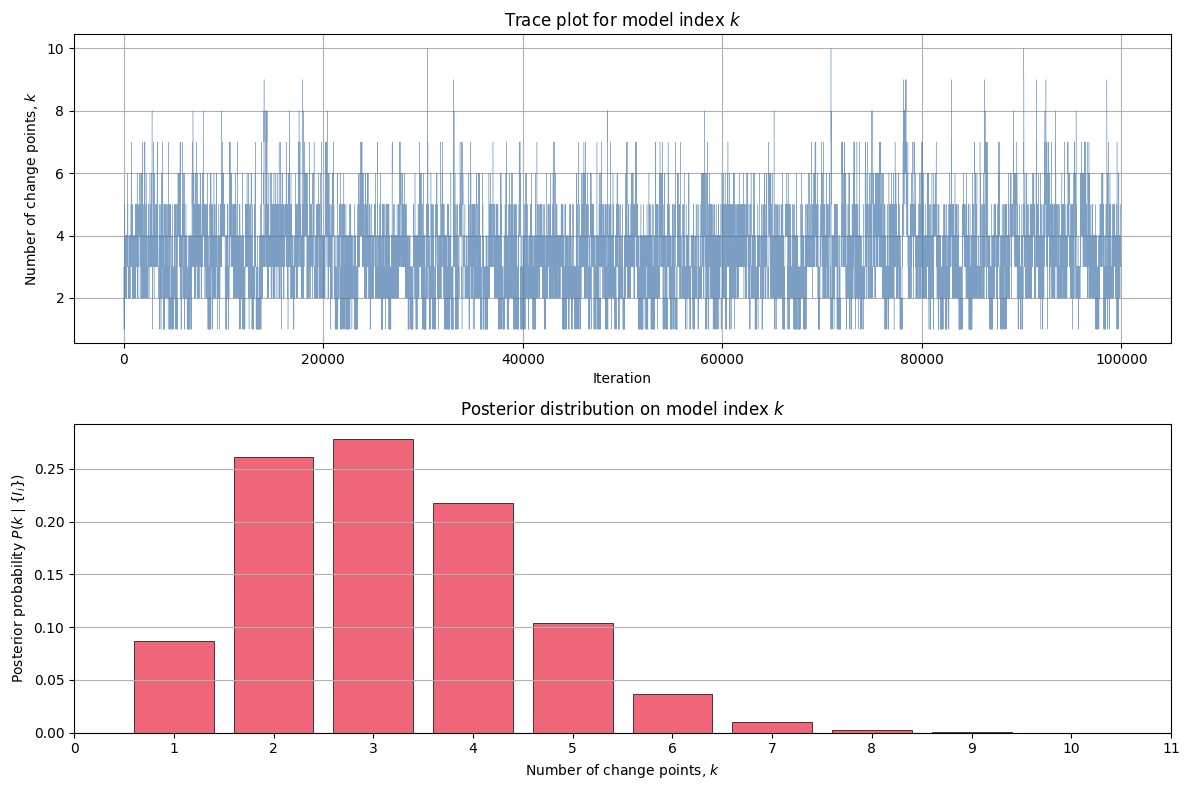

In [13]:
import matplotlib.pyplot as plt
from coalmine.plotting import CB_COLOURS

# Extract the model index k for each state in the chain
k_trace = np.array([(len(state) - 1) // 2 for state in sampler.chain])

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# --- Trace plot for k ---
ax = axes[0]
ax.plot(k_trace, linewidth=0.3, alpha=0.7, color=CB_COLOURS[0])
ax.set_xlabel("Iteration")
ax.set_ylabel("Number of change points, $k$")
ax.set_title("Trace plot for model index $k$")
ax.grid(True)

# --- Posterior on k ---
burn_in = 1_000  # discard initial burn-in
k_post = k_trace[burn_in:]
k_vals, k_counts = np.unique(k_post, return_counts=True)
k_probs = k_counts / k_counts.sum()

ax = axes[1]
ax.bar(k_vals, k_probs, color=CB_COLOURS[1], edgecolor="black", linewidth=0.5)
ax.set_xlabel("Number of change points, $k$")
ax.set_ylabel("Posterior probability $P(k \\mid \\{I_i\\})$")
ax.set_title("Posterior distribution on model index $k$")
ax.set_xticks(np.arange(0, k_vals.max() + 2))
ax.grid(True, axis="y")

fig.tight_layout()

# MAP estimate
k_map = k_vals[np.argmax(k_probs)]
print(f"MAP number of change points: k = {k_map}")
print(f"Posterior probabilities for top values:")
sorted_idx = np.argsort(-k_probs)
for i in sorted_idx[:5]:
    print(f"  k = {k_vals[i]:2d}: P(k|data) = {k_probs[i]:.4f}")

from coalmine.plotting import savefig
savefig(fig, "q5b_rjmcmc_k")


### c) Inferred rate $x(t)$ marginalised over $k$

PosixPath('/Users/rowandauria/Documents/MPhil/S2/s2-coursework/figs/q5c_inferred_rate')

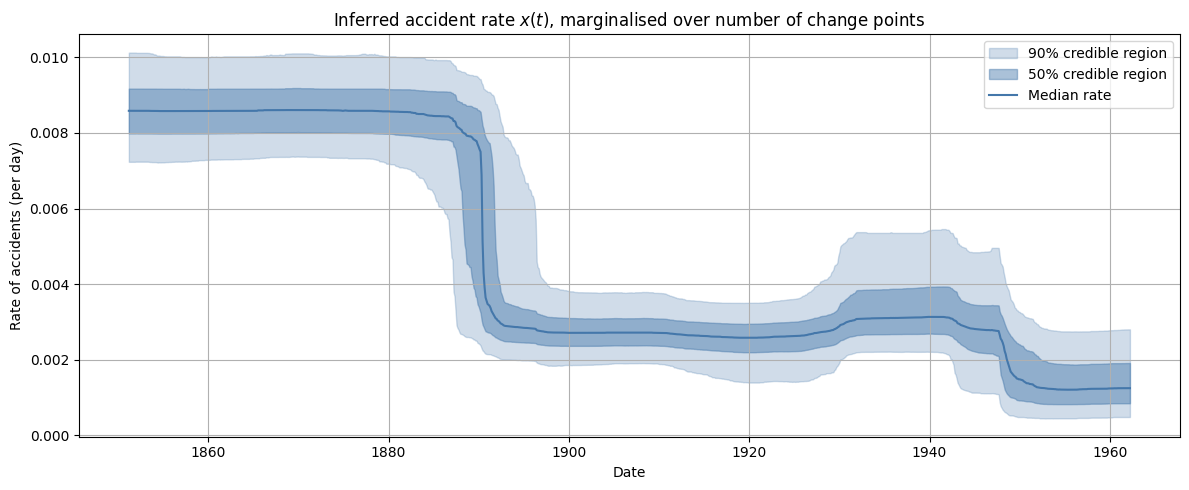

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from coalmine.constants import L, START_DATE
from coalmine.plotting import CB_COLOURS

# Evaluate the rate function x(t) for each post-burn-in sample on a time grid
burn_in = 2_000
chain_post = sampler.chain[burn_in:]
n_samples = len(chain_post)

t_grid = np.linspace(0, L, 1000)
rates = np.zeros((n_samples, len(t_grid)))

for i, state in enumerate(chain_post):
    k = (len(state) - 1) // 2
    change_points = state[:k]
    poisson_rates = state[k:2*k+1]
    # For each time point, find which segment it falls in
    idx = np.searchsorted(change_points, t_grid, side="right")
    rates[i] = poisson_rates[idx]

# Compute percentiles at each time point
median = np.percentile(rates, 50, axis=0)
lo_90 = np.percentile(rates, 5, axis=0)
hi_90 = np.percentile(rates, 95, axis=0)
lo_50 = np.percentile(rates, 25, axis=0)
hi_50 = np.percentile(rates, 75, axis=0)

# Convert time grid to dates for the x-axis
dates = START_DATE + pd.to_timedelta(t_grid, unit="D")

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(dates, lo_90, hi_90, alpha=0.25, color=CB_COLOURS[0], label="90% credible region")
ax.fill_between(dates, lo_50, hi_50, alpha=0.45, color=CB_COLOURS[0], label="50% credible region")
ax.plot(dates, median, linewidth=1.5, color=CB_COLOURS[0], label="Median rate")
ax.set_xlabel("Date")
ax.set_ylabel("Rate of accidents (per day)")
ax.set_title("Inferred accident rate $x(t)$, marginalised over number of change points")
ax.legend()
ax.grid(True)
fig.tight_layout()

from coalmine.plotting import savefig
savefig(fig, "q5c_inferred_rate")


**Calculating the uncertainty regions.** For each post-burn-in RJMCMC sample, the state encodes a complete step-function rate $x(t)$ with a particular number of change points $k$, change point positions, and segment rates. I evaluate each sample's rate function on a dense grid of 1000 time points spanning the observation period. This produces, at each grid point, an ensemble of rate values drawn from the full model-averaged posterior — samples with different $k$ contribute naturally since the RJMCMC chain explores the joint space of all models. The 50% credible region is the interval between the 25th and 75th percentiles of this ensemble at each time point, and the 90% region spans the 5th to 95th percentiles. The median is the pointwise 50th percentile. These are pointwise credible intervals, not simultaneous bands.

In [15]:
# visited_ks = set(k_trace).__len__()
# if visited_ks < 30:
#     print('WARNING: NOT ALL VALUES OF k EXPLORED')
# else:
#     print('All values of k explored')
print(median)

[0.00858538 0.00858538 0.00858538 0.00858538 0.00858538 0.00858538
 0.00858538 0.00858538 0.00858538 0.00858538 0.00858538 0.00858538
 0.00858538 0.00858507 0.00858507 0.00858507 0.00858507 0.00858507
 0.00858507 0.00858482 0.00858449 0.0085823  0.0085823  0.0085823
 0.00858183 0.00858183 0.00858183 0.00858183 0.00858058 0.00858058
 0.00857867 0.00857867 0.00857841 0.00857841 0.00857841 0.00857841
 0.00857841 0.00857841 0.00857841 0.00857841 0.00857841 0.00857841
 0.00857841 0.00857841 0.00857841 0.00857841 0.00857841 0.00857841
 0.00857841 0.00857841 0.00857841 0.00857841 0.00857841 0.00857841
 0.00857841 0.00857841 0.00857841 0.00857841 0.00857841 0.00857841
 0.00857841 0.00857841 0.00857841 0.00857841 0.00857841 0.00857841
 0.00857841 0.00857841 0.00857841 0.00857841 0.00857841 0.00857841
 0.00857841 0.00857841 0.00857841 0.00857841 0.00857841 0.00857841
 0.00857841 0.00857841 0.00857867 0.00858058 0.00858183 0.00858183
 0.00858183 0.00858183 0.00858183 0.00858183 0.00858183 0.00858